# VAE for Michael acceptors

 N.B. This notebook is based directly on the equivalent notebook for LSTMs and generative models from the excellent tutorial at [ai4chemistry](https://github.com/schwallergroup/ai4chem_course) by the Schwaller group at ETH Zurich.

* [Variational Autoencoder (VAE)](https://pubs.acs.org/doi/10.1021/acscentsci.7b00572) this is the first example of using a `VAE`

In [ ]:
# clone repository to extract the compressed molecular data
!git clone https://github.com/aksub99/molecular-vae.git
import zipfile
zip_ref = zipfile.ZipFile('molecular-vae/data/processed.zip', 'r')
zip_ref.extractall('molecular-vae/data/')
zip_ref.close()

--2025-10-30 19:57:22--  https://raw.githubusercontent.com/schwallergroup/ai4chem_course/generative_models/notebooks/05%20-%20Generative%20Models/data/pretrained.vae.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18455963 (18M) [application/octet-stream]
Saving to: ‘pretrained.vae.pt’

pretrained.vae.pt   100%[===================>]  17.60M  77.1MB/s    in 0.2s    

2025-10-30 19:57:23 (77.1 MB/s) - ‘pretrained.vae.pt’ saved [18455963/18455963]

fatal: destination path 'molecular-vae' already exists and is not an empty directory.


In [2]:
# install other packages required
!pip install rdkit
!pip install molplotly
!pip install torch==2.1
!pip install numpy==1.26
!pip install scikit-learn
!pip install h5py
!pip install dash==2.9.2

ERROR: Could not find a version that satisfies the requirement torch==2.1 (from versions: 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0)
ERROR: No matching distribution found for torch==2.1
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python >=3.9,<3.13; 1.26.1 Requires-Python >=3.9,<3.13
ERROR: Could not find a version that satisfies the requirement numpy==1.26 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0

## Variational Autoencoder (VAE)

In the [original molecular `VAE` paper](https://pubs.acs.org/doi/10.1021/acscentsci.7b00572), they train a neural network model to predict properties in the `Latent Space`. They also show how you can move in the `Latent Space` to go from some starting molecule to another molecules with desired properties. Here, we omit further details and instead try to visually demonstrate what the `Latent Space` is.

# Variational Autoencoder (VAE)

The `Encoder` takes molecules and converts it into a low-dimensional vector and maps it onto a `Gaussian Distribution`. Recall that `Gaussian Distributions` are completely defined by their `mean` and `variance`. Specifically, knowing both the `mean` and `variance` allows you to construct the full `Gaussian Distribution`. The `Latent Vector` is now computed based on the `mean` and `variance` but with some noise added to it. In the image, this noise is drawn from a `Gaussian Distribution`. The job of the `Decoder` is to take this `Latent Vector` and `reconstruct` the input.

In the [original molecular `VAE` paper](https://pubs.acs.org/doi/10.1021/acscentsci.7b00572), they train a neural network model to predict properties in the `Latent Space`. They also show how you can move in the `Latent Space` to go from some starting molecule to another molecules with desired properties. Here, we omit further details and instead try to visually demonstrate what the `Latent Space` is.

**Note:** The `VAE` code from this section is taken from 
[Akshay Subramanian](https://aksub99.github.io/) who reimplemented the original [VAE](https://pubs.acs.org/doi/10.1021/acscentsci.7b00572) in `PyTorch` in this [Jupyter notebook](https://github.com/aksub99/molecular-vae/blob/master/Molecular_VAE.ipynb)

The code is shown here but you do not have to go over anything/everything. It is shown here to highlight the key steps that occur. Some comments have been added to map the big idea of what is happening back to the `VAE` image above.

**Further Note:** There are no tasks in this section

In [3]:
# imports 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
import gzip
import pandas
import h5py
import numpy as np
from __future__ import print_function
import argparse
import os
import h5py
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn import model_selection

In [ ]:
import subprocess
import pandas as pd
# if processed.h5 is not found in data folder,
# we create it from the train.smi (etc.) files we used for the LSTM
if not os.path.exists("data/processed.h5"):
    # Convert SMI files to one HDF5 file for VAE
    dfs = []
    for file in ["train","valid","test"]:
        dfs.append(pd.read_csv(f"data/{file}.smi", sep=" ").rename(columns={"SMILES":"structure"}))
    df = pd.concat(dfs,axis=0)
    print(df.shape)
    df.to_hdf(f"data/michael.h5",key="table")
    # Preprocess hdf5 file (train-test split, tokenization)
    subprocess.run("python keras-molecules/preprocess.py data/michael.h5 data/processed.h5", shell=True)

In [5]:
def one_hot_array(i, n):
    return map(int, [ix == i for ix in range(n)])

def one_hot_index(vec, charset):
    return map(charset.index, vec)

def smiles_to_hot(smi, charset):
    assert not ((set(smi) ^ set(charset)) & set(smi))
    assert len(smi) <= 120
    smi = smi.ljust(120)
    l = len(charset)
    return np.array([list(one_hot_array(idx,l)) for idx in one_hot_index(smi,charset)])

def from_one_hot_array(vec):
    oh = np.where(vec == 1)
    if oh[0].shape == (0, ):
        return None
    return int(oh[0][0])

def decode_smiles_from_indexes(vec, charset):
    return "".join(map(lambda x: charset[x], vec)).strip()

def load_dataset(filename, split = True):
    h5f = h5py.File(filename, 'r')
    if split:
        data_train = h5f['data_train'][:]
    else:
        data_train = None
    data_test = h5f['data_test'][:]
    charset =  h5f['charset'][:]
    h5f.close()
    if split:
        return (data_train, data_test, charset)
    else:
        return (data_test, charset)

In [6]:
# the main code for the VAE
class MolecularVAE(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder related blocks
        self.conv_1 = nn.Conv1d(120, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.linear_0 = nn.Linear(70, 435)
        self.linear_1 = nn.Linear(435, 292)
        self.linear_2 = nn.Linear(435, 292)

        # decoder related blocks
        self.linear_3 = nn.Linear(292, 292)
        self.gru = nn.GRU(292, 501, 3, batch_first=True)
        self.linear_4 = nn.Linear(501, 33)

        # activation function 
        self.relu = nn.ReLU()
        
    def encode(self, x):
        # forward pass through encoder
        x = self.relu(self.conv_1(x))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.view(x.size(0), -1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, z_mean, z_logvar):
        # recall in the VAE figure, noise is added
        # epsilon is the noise
        # epsilon = 1e-2 * torch.randn_like(z_logvar)
        epsilon = 1e-1 * torch.randn_like(z_logvar)
        # return the latent vector (this is what the decoder will use to reconstruct the input)
        return torch.exp(0.5 * z_logvar) * epsilon + z_mean

    def decode(self, z):
        # forward pass through decoder to go from latent vector back to a molecule
        z = F.selu(self.linear_3(z))
        z = z.view(z.size(0), 1, z.size(-1)).repeat(1, 120, 1)
        output, hn = self.gru(z)
        out_reshape = output.contiguous().view(-1, output.size(-1))
        y0 = F.softmax(self.linear_4(out_reshape), dim=1)
        y = y0.contiguous().view(output.size(0), -1, y0.size(-1))
        return y

    def forward(self, x):
        # the overall forward pass takes the input, passes it to the encoder and then decoder
        # first encode your input to get the mean and variance of the Gaussian distribution it is mapped to
        z_mean, z_logvar = self.encode(x)
        # get the latent vector taking the mean and variance above and adding noise to it
        z = self.sampling(z_mean, z_logvar)
        # decode the latent vector, z, to reconstruct a molecule
        return self.decode(z), z_mean, z_logvar
    
def vae_loss(x_decoded_mean, x, z_mean, z_logvar):
    # the loss function is a combination of 2 quantities:
    #     1. "reconstruction loss" which measures how different the reconstructed molecule 
    #        is to the original. We would want them to be similar
    #     2. "Kullback–Leibler (KL) divergence". We are trying to approximate the distribution
    #         of the latent vector with a Gaussian distribution. The KL divergence measure how "off" we are
    reconstruction_loss = F.binary_cross_entropy(x_decoded_mean, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
    return reconstruction_loss + kl_loss

# 1. Re-training the VAE 

In [7]:
# !rm -R 'molecular-vae'
# !git clone https://github.com/aksub99/molecular-vae.git
import zipfile
zip_ref = zipfile.ZipFile('molecular-vae/data/processed.zip', 'r')
zip_ref.extractall('molecular-vae/data/')
zip_ref.close()


In [ ]:
from tqdm import tqdm

def vae_loss(x_decoded_mean, x, z_mean, z_logvar):
    xent_loss = F.binary_cross_entropy(x_decoded_mean, x, reduction='sum') # 'sum'
    # try reducing kl weighting to avoid posterior collapse (original: -0.5)
    kl_loss = -0.1 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
    return xent_loss + kl_loss

def ann_vae_loss(x_decoded_mean, x, z_mean, z_logvar, epoch):
    beta = min(1.0, epoch / 50)
    xent_loss = F.binary_cross_entropy(x_decoded_mean, x, reduction='sum') # 'sum'
    # try reducing kl weighting to avoid posterior collapse (original: -0.5)
    kl_loss = -beta * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
    # print(f"xent_loss: {xent_loss:.2f}, kl_loss: {kl_loss:.2f}")
    return xent_loss + kl_loss

# data_train, data_test, charset = load_dataset("molecular-vae/data/processed.h5")
data_train, data_test, charset = load_dataset('data/processed.h5')
charset = [c.decode("utf-8") for c in charset]
print(data_train.shape)
print(data_test.shape)
print(charset)
print()

data_train = torch.utils.data.TensorDataset(torch.from_numpy(data_train))
train_loader = torch.utils.data.DataLoader(data_train, batch_size=256, shuffle=True) #batch_size=250

torch.manual_seed(10)

epochs = 30 
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MolecularVAE().to(device)
optimizer = optim.Adam(model.parameters())

def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(train_loader):
        data = data[0].to(device)
        optimizer.zero_grad()
        output, mean, logvar = model(data)
        
        if batch_idx==0:
              inp = data.cpu().numpy()
              outp = output.cpu().detach().numpy()
              lab = data.cpu().numpy()
              print("Input:")
              print(decode_smiles_from_indexes(map(from_one_hot_array, inp[0]), charset))
              print("Label:")
              print(decode_smiles_from_indexes(map(from_one_hot_array, lab[0]), charset))
              sampled = outp[0].reshape(1, 120, len(charset)).argmax(axis=2)[0]
              print("Output:")
              print(decode_smiles_from_indexes(sampled, charset))
        
        loss = vae_loss(output, data, mean, logvar)
        # loss = ann_vae_loss(output, data, mean, logvar, epoch)
        loss.backward()
        train_loss += loss
        optimizer.step()
#         if batch_idx % 100 == 0:
#             print(f'{epoch} / {batch_idx}\t{loss:.4f}')
    print('train', train_loss / len(train_loader.dataset))
    return train_loss / len(train_loader.dataset)

for epoch in tqdm(range(1, epochs + 1)):
    train_loss = train(epoch)

# Save trained model
if not os.path.exists("vae"): os.mkdir("vae")
torch.save(model.state_dict(), "vae/retrained.vae.pt")

# Free up memory once training is done
with torch.no_grad(): torch.cuda.empty_cache()

(201861, 120, 33)
(50466, 120, 33)
['(', 's', '/', '-', ']', ' ', '\\', '2', 'c', 'O', '5', '+', 'C', '=', '4', 'r', '#', 'P', '[', 'H', 'S', ')', 'o', 'l', '3', 'B', '@', 'n', 'I', 'N', 'F', '1', 'i']



  0%|          | 0/30 [00:00<?, ?it/s]

Input:
CC(C)(C)Oc1ccc(cc1)CCNC(=O)C2=CCCCC2
Label:
CC(C)(C)Oc1ccc(cc1)CCNC(=O)C2=CCCCC2
Output:
OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO


  3%|▎         | 1/30 [01:41<49:15, 101.92s/it]

train tensor(130.2497, device='cuda:0', grad_fn=<DivBackward0>)
Input:
C[C@H](Cc1cccnc1)NC(=O)C2=CCOCC2
Label:
C[C@H](Cc1cccnc1)NC(=O)C2=CCOCC2
Output:
CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC


...

train tensor(34.0860, device='cuda:0', grad_fn=<DivBackward0>)
Input:
C[C@H](COC)NC(=O)/C=C/c1cncs1
Label:
C[C@H](COC)NC(=O)/C=C/c1cncs1
Output:
C[C@H](COC)NC(=O)/C=C/c1cccs1


 97%|█████████▋| 29/30 [49:55<01:43, 103.17s/it]

train tensor(35.8236, device='cuda:0', grad_fn=<DivBackward0>)
Input:
C1C[C@@]2(CC[NH2+]C2)CN(C1)C(=O)/C=C\C3CC3
Label:
C1C[C@@]2(CC[NH2+]C2)CN(C1)C(=O)/C=C\C3CC3
Output:
C1C[C@@H](CC[CH2+]CC)C(CC)))((O)/CCCCCCCCC


100%|██████████| 30/30 [51:38<00:00, 103.30s/it]

train tensor(34.4290, device='cuda:0', grad_fn=<DivBackward0>)


# 2. Generating molecules (now with noise)

In [ ]:
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from tqdm import tqdm

# initiate an instance of the MolecularVAE 
pretrained_vae = MolecularVAE()
# load the pre-trained model (we provide this)
    
# data_train, data_test, charset = load_dataset("molecular-vae/data/processed.h5")
# charset = [c.decode("utf8") for c in charset]
# pretrained_vae.load_state_dict(torch.load('pretrained.vae.pt'))

data_train, data_test, charset = load_dataset("data/processed.h5")
charset = [c.decode("utf8") for c in charset]
pretrained_vae.load_state_dict(torch.load('vae/retrained.vae.pt'))


molec_1 = data_train[2]
smiles_1 = decode_smiles_from_indexes(molec_1.argmax(axis=1),charset)

mols = []
with torch.no_grad():
    for seed in tqdm(range(500)):
        # torch.manual_seed(seed)
        X_1 = torch.from_numpy(molec_1[np.newaxis, ...]).type(torch.float)
        X_r, z_1 = pretrained_vae.forward(X_1)[:2]
        vector = X_r.argmax(axis=2)[0]
        smiles = decode_smiles_from_indexes(vector,charset)
        try: mols.append(Chem.MolFromSmiles(smiles))
        except: pass

100%|██████████| 500/500 [00:06<00:00, 71.93it/s]


In [8]:
from rdkit.Chem import Draw
smiles_successes = np.unique([Chem.MolToSmiles(m) for m in mols if m]).tolist()
print(smiles_1)
print(smiles_successes)

CCc1cccc(c1)NC(=O)/C=C(\C)/Cc2ccccc2OC
['CCc1cc(NC(=O)/C=C(\\C)Cc2ccccc2OC)ccn1', 'CCc1ccc(NC(=O)/C=C(\\C)Cc2ccccc2OC)cc1', 'CCc1cccc(NC(=O)/C=C(/C)CCc2ccccc2OC)c1', 'CCc1cccc(NC(=O)/C=C(\\C)CC2C=CC=CC=C2C)c1', 'CCc1cccc(NC(=O)/C=C(\\C)CC2C=CC=CC=C2O)c1', 'CCc1cccc(NC(=O)/C=C(\\C)Cc2ccccc2OC)c1', 'CCc1cccc(NC(=O)/C=C(\\C)Cc2ccccc2OC)n1', 'CCc1cccc(NC(=O)/C=C(\\C)Cc2ccccc2OCl)c1', 'CCc1cccc(NC(=O)/C=C(\\C)Cc2ccccc2OO)c1', 'CCc1cccc(NC(=O)C=C(C)Cc2ccccc2OC)c1', 'CCc1cccc(NC(=O)C=C(C)Cc2ccccc2OO)c1']


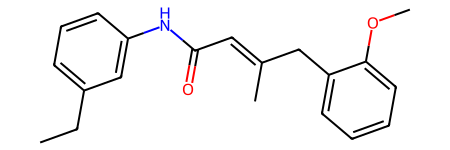

In [9]:
Chem.MolFromSmiles(smiles_1)

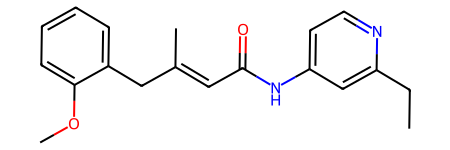

In [10]:
Chem.MolFromSmiles(smiles_successes[0])

## Test model reconstruction accuracy (qualitative)

In [ ]:
pretrained_vae = MolecularVAE()
pretrained_vae.load_state_dict(torch.load('vae/retrained.vae.pt'))
data_train, data_test, charset = load_dataset('data/processed.h5')
charset = [c.decode("utf-8") for c in charset]

data = data_test[:256]
print(data.shape)
# optimizer.zero_grad()
output, mean, logvar = pretrained_vae(torch.from_numpy(data))

inp = data
outp = output
lab = data
print("Input:")
print(decode_smiles_from_indexes(map(from_one_hot_array, inp[0]), charset))
print("Label:")
print(decode_smiles_from_indexes(map(from_one_hot_array, lab[0]), charset))
sampled = outp[0].reshape(1, 120, len(charset)).argmax(axis=2)[0]
print("Output:")
print(decode_smiles_from_indexes(sampled, charset))

loss = vae_loss(output, torch.from_numpy(data), mean, logvar)
xent_loss = F.binary_cross_entropy(output, torch.from_numpy(data), reduction='sum')
kl_loss = -0.1 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
print(f"Recon. loss: {xent_loss}, KLD loss: {kl_loss}") #!!! (sum)
xent_loss = F.binary_cross_entropy(output, torch.from_numpy(data), reduction='mean')
kl_loss = -0.1 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
print(f"Recon. loss: {xent_loss}, KLD loss: {kl_loss}") #!!! (mean)

(256, 120, 33)
Input:
Cc1ncc(s1)/C=C\C(=O)N[C@H](C)C(=O)[O-]
Label:
Cc1ncc(s1)/C=C\C(=O)N[C@H](C)C(=O)[O-]
Output:
Cc1ncc(s1)/C=C\C(=O)N[C@H](C)C(=O)[O-]
Recon. loss: 9059.025390625, KLD loss: 586.095458984375
Recon. loss: 0.008936065249145031, KLD loss: 0.007840531878173351


In [ ]:
exact = 0 
for i in range(100):
    print("Input:")
    insmi = decode_smiles_from_indexes(map(from_one_hot_array, inp[i]), charset)
    print(decode_smiles_from_indexes(map(from_one_hot_array, inp[i]), charset))
    print("Output:")
    sampled = outp[i].reshape(1, 120, len(charset)).argmax(axis=2)[0]
    outsmi = decode_smiles_from_indexes(sampled, charset)
    print(outsmi)
    if outsmi == insmi: exact += 1
    print()
print(exact)

Input:
Cc1ncc(s1)/C=C\C(=O)N[C@H](C)C(=O)[O-]
Output:
Cc1ncc(s1)/C=C\C(=O)N[C@H](C)C(=O)[O-]

Input:
C[C@@H]1CCN(C[C@@H](O1)C)C(=O)C2=CC[C@@H](C2)[NH3+]
Output:
C[C@@H]1CC(CC[C@@H]1C)C))C(=))CCCC[C@@@]CCC)[HH+]]

Input:
C[C@@H](CC(=O)C)NC(=O)/C=C\C1CCC1
Output:
C[C@@H](CC(=O)N)NC(=O)/C=C\C1CCC1

Input:
CN(C)c1cc[nH+]c(c1)NC(=O)/C=C\SC
Output:
CN(C)c1cc[ccccc11F)NC(=O)/C=C\SO

Input:
C/C=C(\C)/C(=O)OCc1nc(nn1C)C2CC2
Output:
C/C=C(\C)/C(=O)OCc1ccnnn11)CCCC2

Input:
CNC(=O)CN(C)C(=O)C=C1CCCCC1
Output:
CNC(=O)NNC))C(=O)C=C1CCCCC1

Input:
Cc1cccc(c1)/C=C/C(=O)Nc2c(cc(cc2F)C(=O)C)F
Output:
Cc1ccccnc1)/C=C\C(=O)Nc2cccccc2)CC(())(F)F

Input:
C[C@H]1C[C@@H](CCN1C(=O)C=C2CCCC2)[NH3+]
Output:
C[C@H]1C[C@@H](CCN1C(=O)C=C2CCC2))[[N33+

Input:
C/C=C\C(=O)N[C@@H]1CC[NH+]2[C@H]1CCCC2
Output:
C/C=C\C(=O)N[C@@H]1C[[HH]2CCC@@]1CCCC

Input:
Cc1cc(n(n1)C(C)(C)C)NC(=O)/C=C/c2ccc3c(c2)cc[nH]3
Output:
Cc1cc(c(n1)C(C(CCCCC)C(=O)/C=C\c2ccc3c(c2)cc[nH]3

Input:
CC(C)[C@@H](c1ccc(cc1)OC)NC(=O)/C=C\c2cccs2
Output:

: 